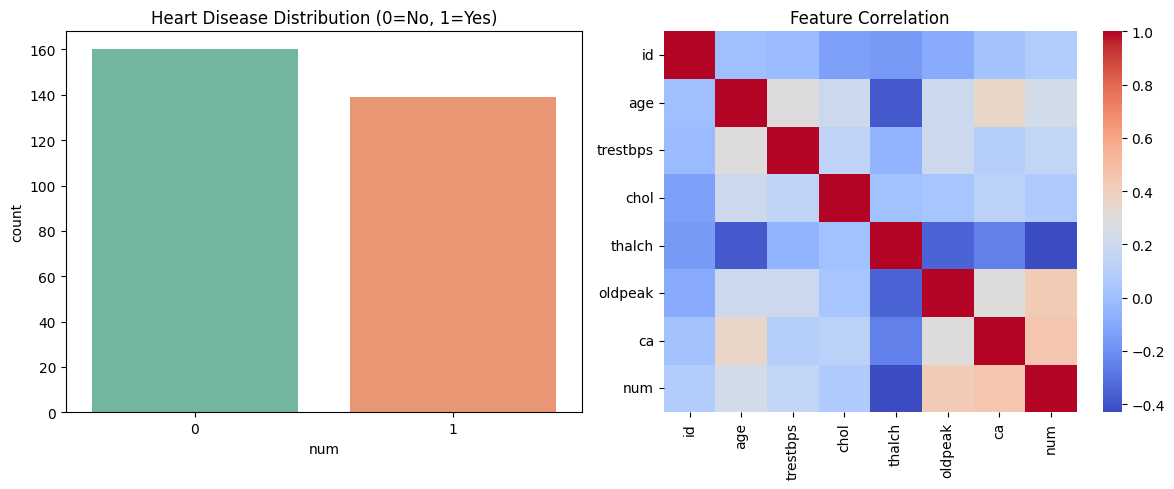


MODEL ACCURACY: 0.92

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.91      0.93        35
           1       0.88      0.92      0.90        25

    accuracy                           0.92        60
   macro avg       0.91      0.92      0.91        60
weighted avg       0.92      0.92      0.92        60



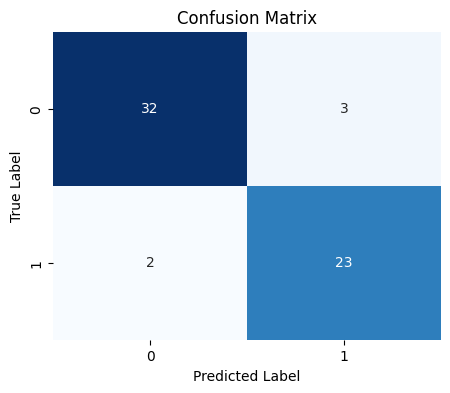

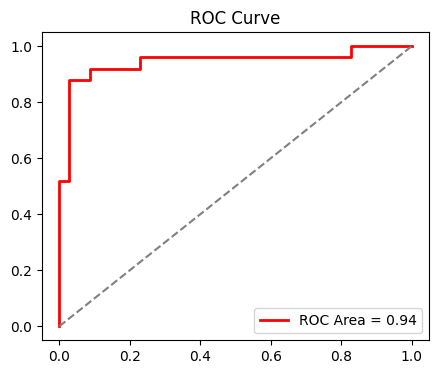

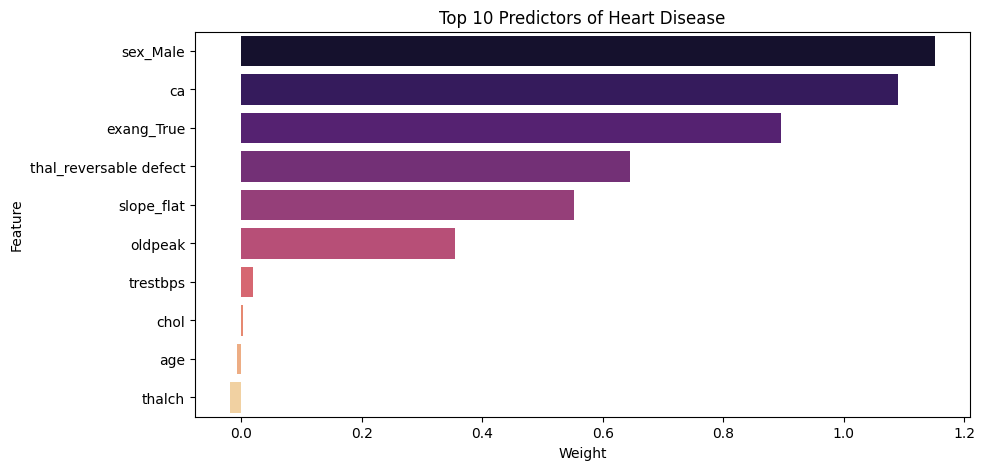

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc, classification_report

# Load and preprocess data
df = pd.read_csv('heart_disease_uci.csv')

# Handle different possible column names for the target
target_col = 'num' if 'num' in df.columns else 'target'
# Convert to binary classification (0 = no disease, 1 = disease)
df[target_col] = df[target_col].apply(lambda x: 1 if x > 0 else 0)
df = df.dropna()

# Exploratory Data Analysis
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(x=target_col, data=df, hue=target_col, palette='Set2', legend=False)
plt.title("Heart Disease Distribution (0=No, 1=Yes)")

plt.subplot(1, 2, 2)
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=False, cmap='coolwarm')
plt.title("Feature Correlation")

plt.tight_layout()
plt.show()

# Feature engineering: remove metadata and encode categories
X = df.drop([target_col, 'id', 'dataset'], axis=1, errors='ignore')
X = pd.get_dummies(X, drop_first=True)
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model training
model = LogisticRegression(max_iter=3000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Output metrics
print("\n" + "="*30)
print(f"MODEL ACCURACY: {accuracy_score(y_test, y_pred):.2f}")
print("="*30)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Visualization of results
plt.figure(figsize=(5, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()



# ROC Curve calculation and plotting
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, color='red', lw=2, label=f'ROC Area = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()



# Extract and plot top 10 important features
importance = pd.DataFrame({'Feature': X.columns, 'Weight': model.coef_[0]})
importance = importance.sort_values(by='Weight', ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x='Weight', y='Feature', data=importance, hue='Feature', palette='magma', legend=False)
plt.title("Top 10 Predictors of Heart Disease")
plt.show()